# 1. Generative classifiers

Your task is to implement the following three generative classifiers (Naive Bayes, LDA and QDA). A custom implementation of f1 score must be used for scoring (calculated using tp, tn, fp, fn).

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
import seaborn as sns

In [ ]:

class NaiveBayes:
    def __init__(self, distr='Gaussian'):
        self.distr = distr
        self.classes = None
        self.stats = {}

    def get_stats(self, X):
        mean = np.mean(X, axis=0)
        var = np.var(X, axis=0)
        return mean, var

    def pdf(self, x, mean, var):
        eps = 1e-9
        coeff = 1.0 / np.sqrt(2.0 * np.pi * var + eps)
        exponent = np.exp(-(x - mean)**2 / (2.0 * var + eps))
        return coeff * exponent

    def fit(self, X_train, y_train):
        self.classes = np.unique(y_train)
        n_rows, n_cols = X_train.shape

        for c in self.classes:
            X_c = X_train[y_train == c]
            mean, var = self.get_stats(X_c)
            prior = X_c.shape[0] / n_rows
            self.stats[c] = {'mean': mean, 'var': var, 'prior': prior}

    def predict_proba(self, X_test):
        n_samples = X_test.shape[0]
        n_classes = len(self.classes)
        probs = np.zeros((n_samples, n_classes))

        for i, x in enumerate(X_test):
            for j, c in enumerate(self.classes):
                prior = np.log(self.stats[c]['prior'])
                mean = self.stats[c]['mean']
                var = self.stats[c]['var']
                likelihood = np.sum(np.log(self.pdf(x, mean, var) + 1e-9))
                probs[i, j] = prior + likelihood
        return probs

    def predict(self, X_test):
        probs = self.predict_proba(X_test)
        return self.classes[np.argmax(probs, axis=1)]

    def score(self, X_test, y_test):
        y_pred = self.predict(X_test)
        y_test = np.array(y_test)
        tp = np.sum((y_test == 1) & (y_pred == 1))
        fp = np.sum((y_test == 0) & (y_pred == 1))
        fn = np.sum((y_test == 1) & (y_pred == 0))

        if (tp + fp) == 0: precision = 0
        else: precision = tp / (tp + fp)

        if (tp + fn) == 0: recall = 0
        else: recall = tp / (tp + fn)

        if (precision + recall) == 0: f1 = 0
        else: f1 = 2 * (precision * recall) / (precision + recall)

        return f1

In [ ]:
class LinearDA:
    def __init__(self):
        self.classes = None
        self.means = {}
        self.priors = {}
        self.cov = None
        self.cov_inv = None

    def get_stats(self, X):
        return np.mean(X, axis=0)

    def fit(self, X_train, y_train):
        self.classes = np.unique(y_train)
        n_samples, n_features = X_train.shape
        self.cov = np.zeros((n_features, n_features))

        for c in self.classes:
            X_c = X_train[y_train == c]
            self.means[c] = self.get_stats(X_c)
            self.priors[c] = X_c.shape[0] / n_samples
            self.cov += (X_c.shape[0] - 1) * np.cov(X_c.T)

        self.cov /= (n_samples - len(self.classes))
        self.cov_inv = np.linalg.pinv(self.cov)

    def ldf(self, x, mean, cov_inv, prior):
        term1 = x.T @ cov_inv @ mean
        term2 = 0.5 * (mean.T @ cov_inv @ mean)
        term3 = np.log(prior)
        return term1 - term2 + term3

    def predict_proba(self, X_test):

        scores = []
        for x in X_test:
            row_scores = []
            for c in self.classes:
                val = self.ldf(x, self.means[c], self.cov_inv, self.priors[c])
                row_scores.append(val)
            scores.append(row_scores)
        return np.array(scores)

    def predict(self, X_test):
        scores = self.predict_proba(X_test)
        return self.classes[np.argmax(scores, axis=1)]

    def score(self, X_test, y_test):
        y_pred = self.predict(X_test)
        y_test = np.array(y_test)

        tp = np.sum((y_test == 1) & (y_pred == 1))
        fp = np.sum((y_test == 0) & (y_pred == 1))
        fn = np.sum((y_test == 1) & (y_pred == 0))

        if (tp + fp) == 0: precision = 0
        else: precision = tp / (tp + fp)

        if (tp + fn) == 0: recall = 0
        else: recall = tp / (tp + fn)

        if (precision + recall) == 0: f1 = 0
        else: f1 = 2 * (precision * recall) / (precision + recall)

        return f1

In [ ]:
class QuadraticDA:
    def __init__(self):
        self.classes = None
        self.means = {}
        self.priors = {}
        self.covs = {}

    def fit(self, X_train, y_train):
        self.classes = np.unique(y_train)
        n_samples, n_features = X_train.shape

        for c in self.classes:
            X_c = X_train[y_train == c]
            self.means[c] = np.mean(X_c, axis=0)
            self.priors[c] = X_c.shape[0] / n_samples
            self.covs[c] = np.cov(X_c.T)

    def predict_proba(self, X_test):
        scores = []
        for x in X_test:
            row_scores = []
            for c in self.classes:
                mean = self.means[c]
                cov = self.covs[c]
                prior = self.priors[c]
                cov_inv = np.linalg.pinv(cov)
                det = np.linalg.det(cov)

                term1 = -0.5 * np.log(det + 1e-9)
                term2 = -0.5 * (x - mean).T @ cov_inv @ (x - mean)
                term3 = np.log(prior)
                row_scores.append(term1 + term2 + term3)
            scores.append(row_scores)
        return np.array(scores)

    def predict(self, X_test):
        scores = self.predict_proba(X_test)
        return self.classes[np.argmax(scores, axis=1)]

    def score(self, X_test, y_test):
        y_pred = self.predict(X_test)
        y_test = np.array(y_test)

        tp = np.sum((y_test == 1) & (y_pred == 1))
        fp = np.sum((y_test == 0) & (y_pred == 1))
        fn = np.sum((y_test == 1) & (y_pred == 0))

        if (tp + fp) == 0: precision = 0
        else: precision = tp / (tp + fp)

        if (tp + fn) == 0: recall = 0
        else: recall = tp / (tp + fn)

        if (precision + recall) == 0: f1 = 0
        else: f1 = 2 * (precision * recall) / (precision + recall)

        return f1

# 2. Solve classification problem using 'classification.csv' dataset

In [ ]:
df = pd.read_csv('classification.csv')
df.head(5)

,age,ed,employ,address,income,debtinc,creddebt,othdebt,default
0,41,college degree,17,12,176,9.3,11.359392,5.008608,1
1,27,no high school,10,6,31,17.3,1.362202,4.000798,0
2,40,no high school,15,14,55,5.5,0.856075,2.168925,0
3,41,no high school,15,14,120,2.9,2.658720,0.821280,0
4,24,high school,2,0,28,17.3,1.787436,3.056564,1


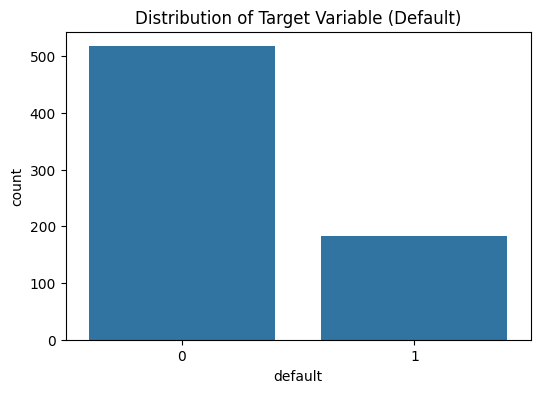

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='default', data=df)
plt.title('Distribution of Target Variable (Default)')
plt.show()

In [ ]:

le = LabelEncoder()
df['ed'] = le.fit_transform(df['ed'])

X = df.drop('default', axis=1).values
y = df['default'].values


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


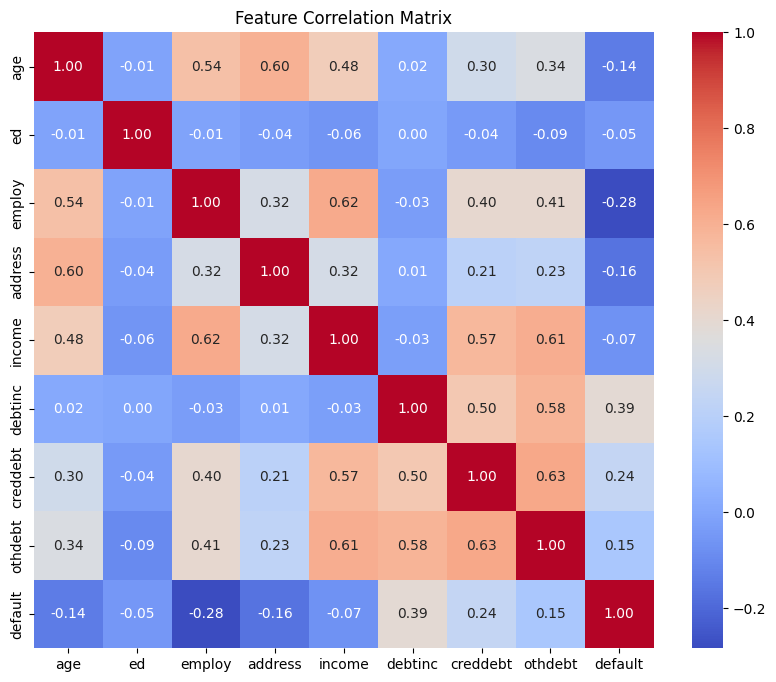

In [ ]:

df_eda = df.copy()
le_eda = LabelEncoder()
df_eda['ed'] = le_eda.fit_transform(df_eda['ed'])


plt.figure(figsize=(10, 8))
sns.heatmap(df_eda.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Feature Correlation Matrix')
plt.show()

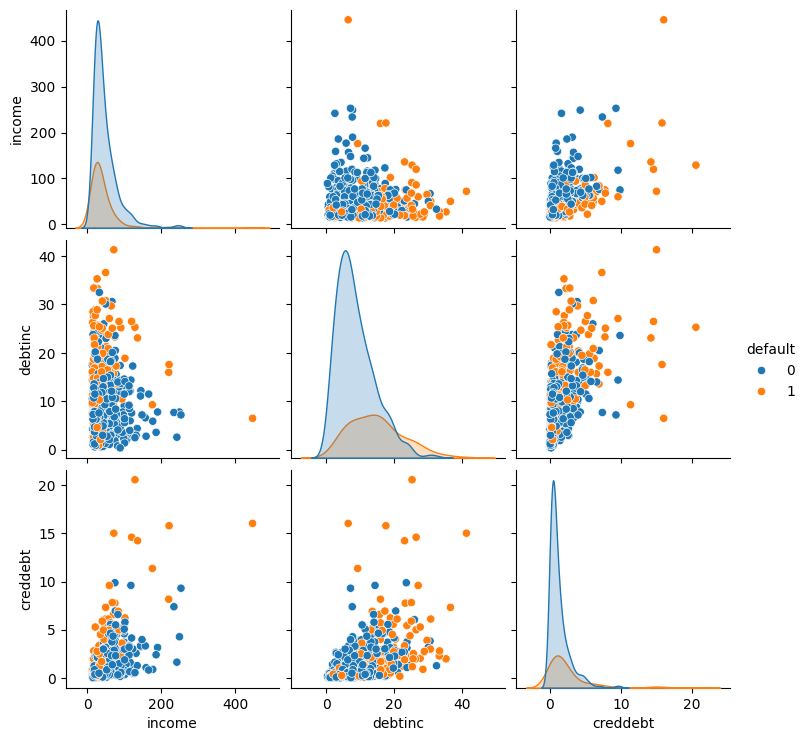

In [ ]:
sns.pairplot(df_eda, hue='default', vars=['income', 'debtinc', 'creddebt'])
plt.show()

In [ ]:
from sklearn.feature_selection import SelectKBest, f_classif

le = LabelEncoder()
df['ed'] = le.fit_transform(df['ed'])

X = df.drop('default', axis=1)
y = df['default']

selector = SelectKBest(score_func=f_classif, k=5)
X_selected = selector.fit_transform(X, y)

selected_indices = selector.get_support(indices=True)
selected_features = X.columns[selected_indices]
print("Selected Features:", selected_features.tolist())

X_train, X_test, y_train, y_test = train_test_split(X_selected, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

Selected Features: ['employ', 'address', 'debtinc', 'creddebt', 'othdebt']


In [ ]:
def calculate_metrics(y_true, y_pred, set_name="Data"):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (tp + tn) / (tp + tn + fp + fn)

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    print(f"--- Metrics for {set_name} ---")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")
    print(f"Confusion Matrix: [TP:{tp}, TN:{tn}, FP:{fp}, FN:{fn}]\n")

    return f1

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import cross_val_score

models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC()
}

best_model = None
best_score = 0
best_name = ""

print("--- Cross Validation Results (Accuracy) ---")
for name, model in models.items():

    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    mean_score = scores.mean()
    print(f"{name}: {mean_score:.4f}")

    if mean_score > best_score:
        best_score = mean_score
        best_model = model
        best_name = name

print(f"\nBest Model: {best_name}")

best_model.fit(X_train, y_train)
print("\n=== Final Evaluation ===")
y_pred_train = best_model.predict(X_train)
calculate_metrics(y_train, y_pred_train, set_name="Train Set")

y_pred_test = best_model.predict(X_test)
calculate_metrics(y_test, y_pred_test, set_name="Test Set")

--- Cross Validation Results (Accuracy) ---
Logistic Regression: 0.8054
Random Forest: 0.7750
SVM: 0.7661

Best Model: Logistic Regression

=== Final Evaluation ===
--- Metrics for Train Set ---
Accuracy:  0.8071
Precision: 0.6947
Recall:    0.4552
F1 Score:  0.5500
Confusion Matrix: [TP:66, TN:386, FP:29, FN:79]

--- Metrics for Test Set ---
Accuracy:  0.8571
Precision: 0.8462
Recall:    0.5789
F1 Score:  0.6875
Confusion Matrix: [TP:22, TN:98, FP:4, FN:16]



np.float64(0.6875)

In [ ]:
print("=== Custom Model Evaluation ===")

X_train_np = np.array(X_train)
X_test_np = np.array(X_test)
y_train_np = np.array(y_train)
y_test_np = np.array(y_test)

print("\n--- Custom Naive Bayes ---")
nb_custom = NaiveBayes()
nb_custom.fit(X_train_np, y_train_np)
y_pred_nb = nb_custom.predict(X_test_np)
calculate_metrics(y_test_np, y_pred_nb, set_name="Naive Bayes Test")


print("\n--- Custom Linear DA ---")
lda_custom = LinearDA()
lda_custom.fit(X_train_np, y_train_np)
y_pred_lda = lda_custom.predict(X_test_np)
calculate_metrics(y_test_np, y_pred_lda, set_name="Linear DA Test")

print("\n--- Custom Quadratic DA ---")
qda_custom = QuadraticDA()
qda_custom.fit(X_train_np, y_train_np)
y_pred_qda = qda_custom.predict(X_test_np)
calculate_metrics(y_test_np, y_pred_qda, set_name="Quadratic DA Test")

=== Custom Model Evaluation ===

--- Custom Naive Bayes ---
--- Metrics for Naive Bayes Test ---
Accuracy:  0.7714
Precision: 0.6364
Recall:    0.3684
F1 Score:  0.4667
Confusion Matrix: [TP:14, TN:94, FP:8, FN:24]


--- Custom Linear DA ---
--- Metrics for Linear DA Test ---
Accuracy:  0.8786
Precision: 0.9200
Recall:    0.6053
F1 Score:  0.7302
Confusion Matrix: [TP:23, TN:100, FP:2, FN:15]


--- Custom Quadratic DA ---
--- Metrics for Quadratic DA Test ---
Accuracy:  0.8214
Precision: 0.7826
Recall:    0.4737
F1 Score:  0.5902
Confusion Matrix: [TP:18, TN:97, FP:5, FN:20]



np.float64(0.5901639344262294)

Visualize the data, do some EDA. The target variable is 'default'. Apply feature selection, feature scaling, cross validation etc. (anything you think is needed). Split the data into train/test, train a classiffication model (whichever model works best, experiment!) and evaluate on the test data. Print the various metrics discussed during the lecture on both sets.

Note: you are permitted to use external libraries for the models themselves, but not for the metrics. You must implement all the metrics yourselves.